In [ ]:
# Deep Learning Image Classification: Fashion MNIST
# Phase 1: Environment Setup & Data Preparation
# In this section, we set up the PyTorch environment and load the Fashion MNIST dataset. 
# We apply standard transformations, including normalization, to stabilize neural network training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np


In [2]:
# Transform: Convert image to PyTorch Tensor and normalize pixel values to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load datasets
train_dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

# Initialize DataLoaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100.0%
100.0%
100.0%
100.0%


In [ ]:
# Phase 2: MLP Model Architecture
# We define a Multi-Layer Perceptron (MLP) architecture. The model flattens the 28x28 input images into a 1D tensor of 784 features, 
# passes them through two hidden layers with ReLU activations, and outputs raw scores (logits) for the 10 classes.

In [3]:
# --- Define the Neural Network ---
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layers(x)

model = MLP()

# Define Loss function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Phase 3: Model Training & Validation Loop
# We train the model over 10 epochs. In each epoch, the model updates its weights using backpropagation on the training set, 
# followed by an evaluation pass on the test set to monitor for overfitting.

In [4]:
# --- Training Configuration ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(10):
    # ---- TRAIN ----
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for X, y in train_loader:
        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for X, y in test_loader:
            outputs = model(X)
            val_loss += loss_fn(outputs, y).item()
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_losses.append(val_loss / len(test_loader))
    val_accs.append(correct / total)

    print(f"Epoch {epoch+1}: Train loss={train_losses[-1]:.4f}, Val loss={val_losses[-1]:.4f}, Acc={val_accs[-1]*100:.2f}%")


Epoch 1: Train loss=0.4899, Val loss=0.4253, Acc=84.72%
Epoch 2: Train loss=0.3674, Val loss=0.4073, Acc=84.84%
Epoch 3: Train loss=0.3304, Val loss=0.3775, Acc=85.57%
Epoch 4: Train loss=0.3050, Val loss=0.3420, Acc=87.76%
Epoch 5: Train loss=0.2854, Val loss=0.3528, Acc=87.39%
Epoch 6: Train loss=0.2714, Val loss=0.3397, Acc=87.65%
Epoch 7: Train loss=0.2553, Val loss=0.3419, Acc=88.18%
Epoch 8: Train loss=0.2423, Val loss=0.3286, Acc=88.41%
Epoch 9: Train loss=0.2308, Val loss=0.3404, Acc=88.31%
Epoch 10: Train loss=0.2190, Val loss=0.3477, Acc=88.14%


In [ ]:
# Phase 4: Model Evaluation & Visualizations
# After training, we visualize the learning curves to check for convergence. We also plot a Confusion Matrix and 
# Class-wise Accuracy to identify which specific clothing items the model struggles to classify.

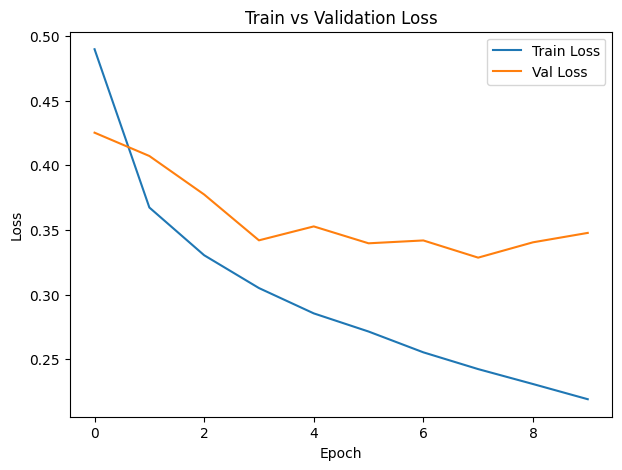

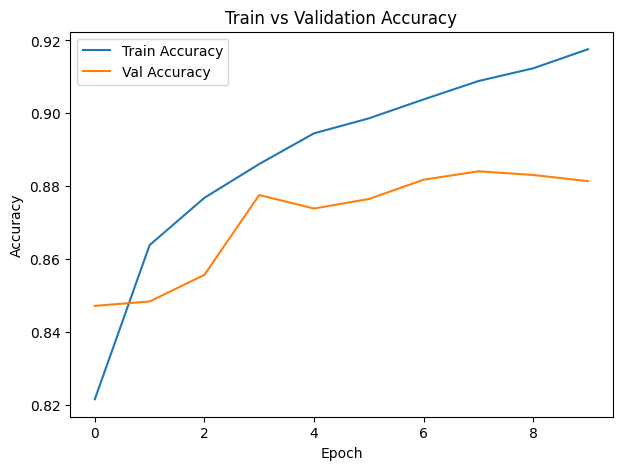

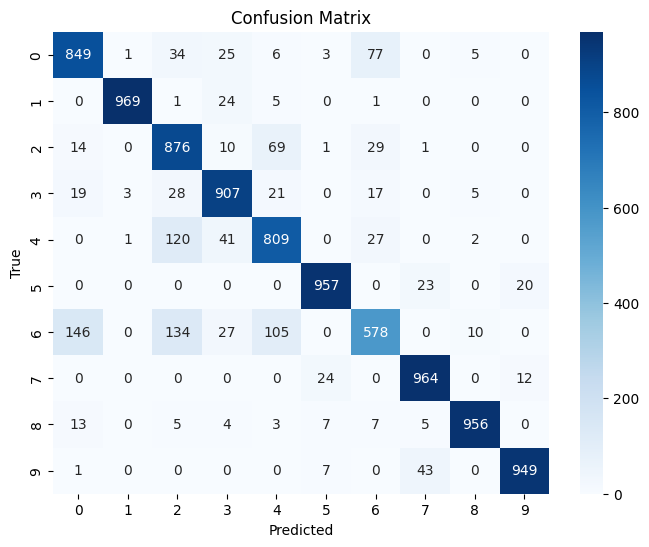

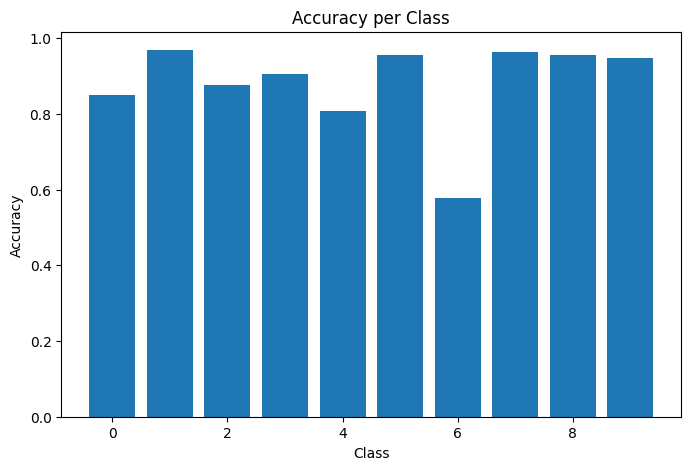

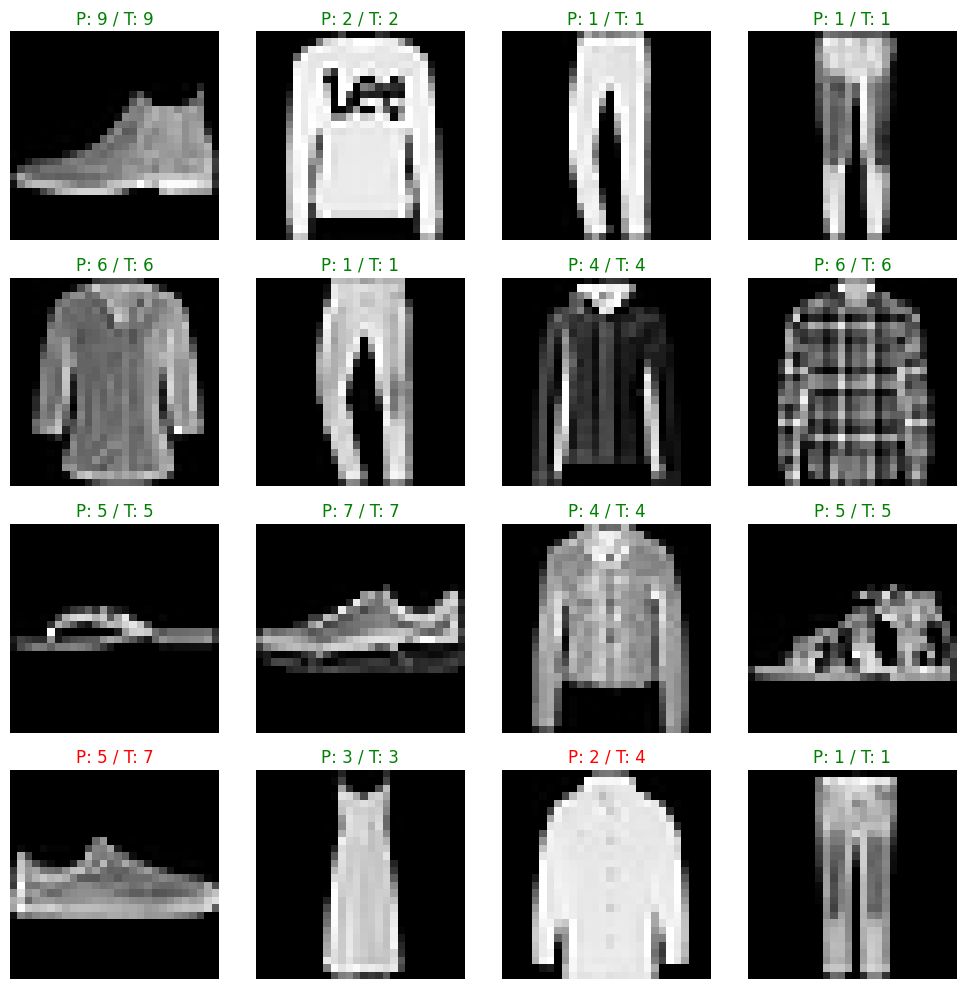

In [5]:
# --- 1. Learning Curves (Loss & Accuracy) ---

plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_curve.png", dpi=200)
plt.show()

# --- 2. Generate Predictions for the Test Set ---
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y.numpy())
        y_pred.extend(predicted.numpy())

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

# --- 4. Accuracy per Class ---
class_acc = []

for i in range(10):
    idx = [j for j in range(len(y_true)) if y_true[j] == i]
    correct = sum(np.array(y_pred)[idx] == i)
    class_acc.append(correct / len(idx))

plt.figure(figsize=(8,5))
plt.bar(range(10), class_acc)
plt.title("Accuracy per Class")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.savefig("class_accuracy.png", dpi=200)
plt.show()

# --- 5. Visualizing Sample Predictions ---
def show_predictions():
    model.eval()
    images, labels = next(iter(test_loader))
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(10, 10))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        color = "green" if preds[i] == labels[i] else "red"
        plt.title(f"P: {preds[i].item()} / T: {labels[i].item()}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig("predictions_grid.png", dpi=200)
    plt.show()

show_predictions()